In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/luisfelipevendramim/m5-forecast-results/m5_forecast_results.csv


**Objetivo**

Utilizar as previsões geradas pelo Notebook "m5-forecasting-models" para calcular:

* Demand Forecast
* Demand Variability
* Safety Stock
* Reorder Point (ROP)
* Days of Inventory
* Inventory Coverage
* Economic Order Quantity (EOQ)

**Estrutura do Notebook:**

1. Carregar previsões
2. Selecionar série
3. Calcular demanda média
4. Calcular volatilidade
5. Safety Stock
6. Reorder Point
7. EOQ
8. Simulação de estoque
9. Dashboard de KPIs
10. Conclusões de negócio

**1. Importações**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

**2. Carregar Forecast**

In [3]:
forecast = pd.read_csv(
    "/kaggle/input/datasets/luisfelipevendramim/m5-forecast-results/m5_forecast_results.csv"
)

forecast.head()

,Actual,XGBoost,LightGBM,Prophet
0,2891,2343.8533,2373.293848,3054.219920
1,3482,3218.9614,3377.397074,2668.880621
2,3306,3040.5186,3045.385243,2658.734318
3,2570,2386.4630,2093.909854,2645.002444
4,2490,2691.5393,2335.932067,3282.045635


**3. Utilizar Melhor Modelo**

In [4]:
forecast["forecast"] = (
    forecast["XGBoost"]
)

**4. Estatísticas da Demanda**

Demanda média prevista:

In [5]:
mean_demand = (
    forecast["forecast"]
    .mean()
)

print(
    f"Average Demand: {mean_demand:.2f}"
)

Average Demand: 2597.35


Desvio Padrão:

In [6]:
std_demand = (
    forecast["forecast"]
    .std()
)

print(
    f"Demand Std: {std_demand:.2f}"
)

Demand Std: 833.22


**5. Definir Lead Time**

In [7]:
lead_time = 7

**6. Safety Stock**

Nível de serviço: 95%

In [8]:
service_level = 1.65

Fórmula:

SS = Zσ sq(LT)

Implementação:

In [9]:
safety_stock = (
    service_level
    *
    std_demand
    *
    np.sqrt(lead_time)
)

print(
    f"Safety Stock: {safety_stock:.0f}"
)

Safety Stock: 3637


**7. Reorder Point**

Demanda durante Lead Time:

In [10]:
demand_during_lead_time = (
    mean_demand
    *
    lead_time
)

ROP:

ROP=Dlt + SS

In [11]:
reorder_point = (
    demand_during_lead_time
    +
    safety_stock
)

print(
    f"ROP: {reorder_point:.0f}"
)

ROP: 21819


**8. Economic Order Quantity**

Premissas:

In [12]:
annual_demand = (
    mean_demand
    * 365
)

ordering_cost = 100

holding_cost = 5

EOQ

EOQ = sq(2DS/H)	

In [13]:
eoq = np.sqrt(
    (
        2
        *
        annual_demand
        *
        ordering_cost
    )
    /
    holding_cost
)

print(
    f"EOQ: {eoq:.0f}"
)

EOQ: 6158


**9. Simulação de Estoque**

Estoque inicial:

In [14]:
current_inventory = 5000

Criar dataframe:

In [15]:
inventory_df = forecast.copy()

inventory_df[
    "inventory"
] = current_inventory

Loop de consumo:

In [16]:
inventory = current_inventory

inventory_history = []

for demand in inventory_df["forecast"]:

    inventory -= demand

    inventory_history.append(
        inventory
    )

Salvar:

In [17]:
inventory_df[
    "inventory"
] = inventory_history

**10. Visualização do Estoque**

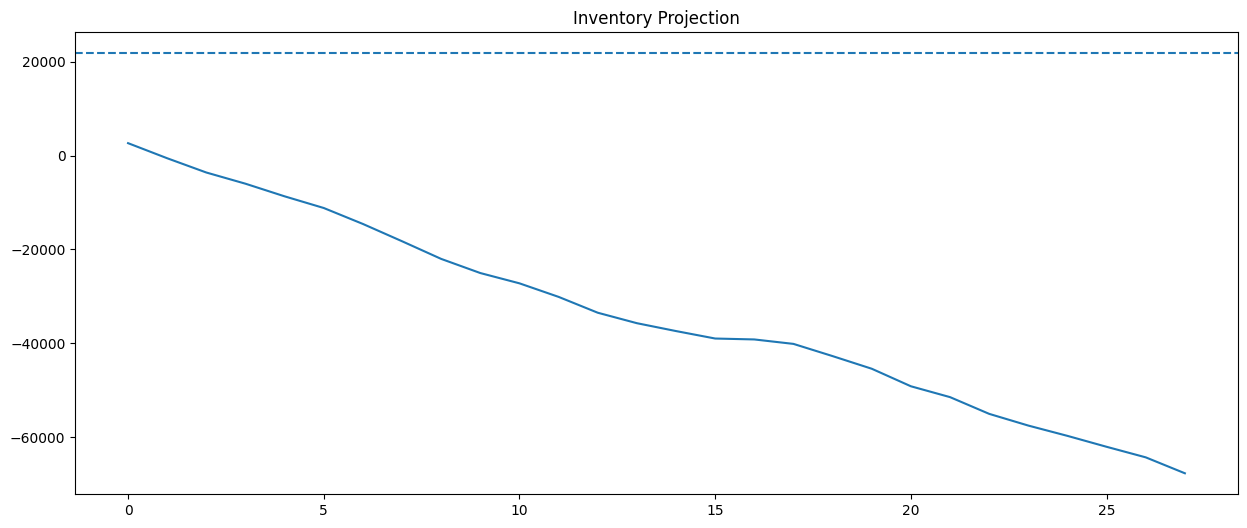

In [18]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    inventory_df["inventory"]
)

plt.axhline(
    reorder_point,
    linestyle="--"
)

plt.title(
    "Inventory Projection"
)

plt.show()

**11. Dias até Ruptura**

In [19]:
stockout_day = (
    inventory_df[
        inventory_df["inventory"] <= 0
    ]
)

In [20]:
if len(stockout_day) > 0:

    print(
        f"Stockout expected in day {stockout_day.index[0]}"
    )

else:

    print(
        "No stockout risk in forecast horizon"
    )

Stockout expected in day 1


**12. Inventory Coverage**

In [21]:
inventory_coverage = (
    current_inventory
    /
    mean_demand
)

print(
    f"Coverage: {inventory_coverage:.1f} days"
)

Coverage: 1.9 days


In [22]:
inventory_results = pd.DataFrame(
    {
        "Safety_Stock": [safety_stock],
        "ROP": [reorder_point],
        "EOQ": [eoq],
        "Coverage": [inventory_coverage],
        "Mean_Demand": [mean_demand],
        "Demand_Std": [std_demand]
    }
)

In [23]:
inventory_results.to_csv(
    "inventory_results.csv",
    index=False
)

In [24]:
inventory_results.head()

,Safety_Stock,ROP,EOQ,Coverage,Mean_Demand,Demand_Std
0,3637.434871,21818.861901,6158.024204,1.925041,2597.346719,833.224942


**13. KPI Dashboard**

In [25]:
kpis = pd.DataFrame(
    {
        "Metric":[
            "Mean Demand",
            "Demand Std",
            "Safety Stock",
            "ROP",
            "EOQ",
            "Inventory Coverage"
        ],

        "Value":[
            round(mean_demand),
            round(std_demand),
            round(safety_stock),
            round(reorder_point),
            round(eoq),
            round(inventory_coverage)
        ]
    }
)

kpis

,Metric,Value
0,Mean Demand,2597
1,Demand Std,833
2,Safety Stock,3637
3,ROP,21819
4,EOQ,6158
5,Inventory Coverage,2


Salvar base:

In [26]:
kpis.to_csv(
    "inventory_kpis.csv",
    index=False
)

**14. Simulação de Cenários**

In [27]:
forecast["optimistic"] = (
    forecast["forecast"]
    * 0.9
)

forecast["base"] = (
    forecast["forecast"]
)

forecast["pessimistic"] = (
    forecast["forecast"]
    * 1.1
)

Salvar base:

In [28]:
forecast.to_csv(
    "forecast_scenarios.csv",
    index=False
)

Visualização:

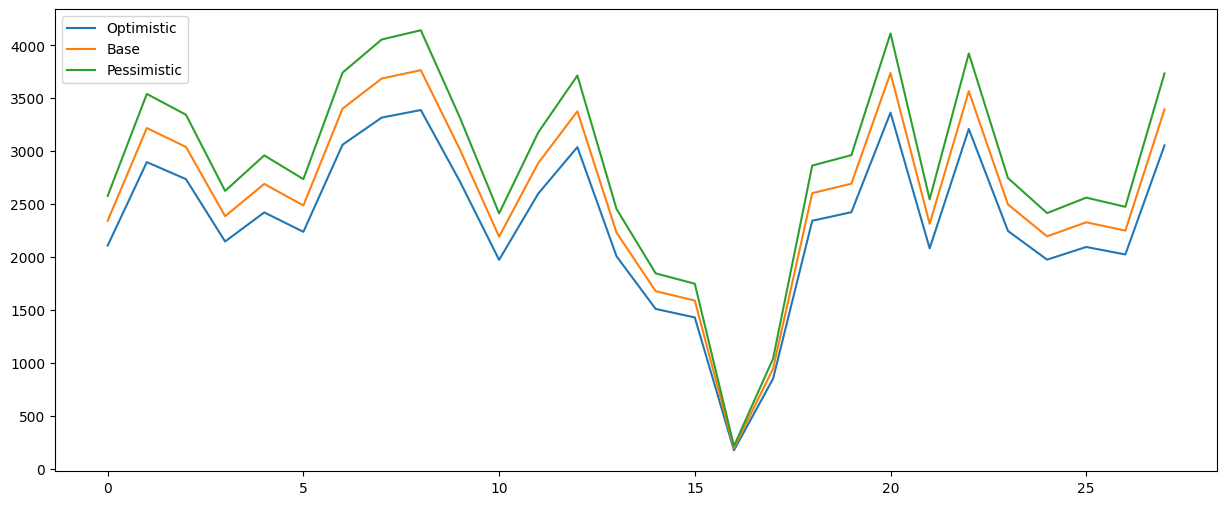

In [29]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    forecast["optimistic"],
    label="Optimistic"
)

plt.plot(
    forecast["base"],
    label="Base"
)

plt.plot(
    forecast["pessimistic"],
    label="Pessimistic"
)

plt.legend()

plt.show()

In [30]:
import os

os.listdir('/kaggle/working')

['.virtual_documents',
 'inventory_kpis.csv',
 'inventory_results.csv',
 'forecast_scenarios.csv']

In [31]:
inventory_df.to_csv(
    "inventory_projection.csv",
    index=False
)

In [32]:
inventory_projection = pd.read_csv(
    "inventory_projection.csv"
)

In [33]:
import os

files = os.listdir('/kaggle/working')

print("Generated files:\n")

for file in files:
    print(file)

Generated files:

.virtual_documents
inventory_kpis.csv
inventory_projection.csv
inventory_results.csv
forecast_scenarios.csv


**15. Inventory Projection**

In [34]:
import plotly.graph_objects as go

fig_inventory = go.Figure()

fig_inventory.add_trace(
    go.Scatter(
        y=inventory_projection["inventory"],
        mode="lines",
        name="Inventory Level"
    )
)

fig_inventory.add_hline(
    y=reorder_point,
    line_dash="dash",
    annotation_text="ROP"
)

fig_inventory.update_layout(
    title="Inventory Projection",
    xaxis_title="Forecast Horizon (Days)",
    yaxis_title="Inventory Units"
)

fig_inventory.show()

O forecast não foi tratado como o produto final. As previsões foram convertidas em decisões operacionais através do cálculo de Safety Stock, Reorder Point e EOQ, permitindo que áreas de planejamento e abastecimento utilizem diretamente os resultados para gestão de inventário.